<div style="text-align: center;">

# Assignment 3

## Hydrolysis of Ethylene Oxide to Ethylene Glycol in a Plug Flow Tubular Reactor

### Manda Sasikala, Noah Herrscher, Benjamin Heuschmid

</div>



## 1. Introduction

Plug flow tubular reactors (PFTRs) are widely used in the chemical industry for continuous production processes because they provide efficient conversion and allow good control over reaction conditions. Compared to batch reactors, PFTRs operate under steady-state conditions and are particularly suitable for large-scale applications where heat transfer and residence time strongly influence reactor performance. For exothermic reactions, temperature control becomes especially important, since heat released during the reaction can significantly affect reaction rates and process stability.

In this work, the hydrolysis of ethylene oxide (EO) with water to produce ethylene glycol (EG) is investigated as an example of an exothermic reaction system. Ethylene glycol is an industrially important chemical used in applications such as antifreeze products and polyester manufacturing. Since the reaction releases heat, reactor operation depends not only on reaction kinetics but also on thermal effects and operating conditions.

The aim of this study is to analyze the behavior of the reaction system in a plug flow tubular reactor by investigating the influence of relevant process parameters. Parameters such as heat transfer, inlet temperature, reactant concentration, and flow-related conditions are evaluated to better understand their impact on reactor temperature and reaction behavior. In addition, the suitability of the reactor concept for the considered reaction system is discussed.


## 2. Mathematical Model
The hydrolysis of ethylene oxide (EO) to ethylene glycol (EG) was modeled using a plug flow tubular reactor (PFTR). The reactor was transformed into an initial value problem using the residence time concept. Constant fluid velocity, liquid-phase operation, and first-order reaction kinetics with respect to EO were assumed.

The residence time was calculated from the reactor length and fluid velocity according to:
$$
\tau = \frac{L}{u}
$$

The investigated reaction is:
$$
EO + H_2O \rightarrow EG
$$
For the PFTR model, axial mixing and radial concentration gradients were neglected. Therefore, the reactor was assumed to behave ideally, and concentration and temperature were considered to vary only along the reactor length.

The reactor operates under steady-state plug flow conditions.

The reaction mixture remains in the liquid phase throughout the reactor.

Fluid velocity is assumed constant along the reactor length.

Axial mixing and radial gradients are neglected.

Heat transfer occurs only through the reactor wall.

The reaction follows first-order kinetics with respect to ethylene oxide.

## 3. Governing Equations

The reactor system was described using mass and energy balances coupled with temperature-dependent reaction kinetics.

### Arrhenius kinetics


$$
k(T)=5.01 \cdot \exp \left(-\frac{72500}{RT}\right)
$$


### Reaction rate equation


$$
r = k(T)c_{EO}
$$


### Component balances

Consumption of ethylene oxide:


$$
\frac{dc_{EO}}{dt} = -r
$$


Formation of ethylene glycol:


$$
\frac{dc_{EG}}{dt} = r
$$


### Energy balance

$$
\frac{dT}{dt}
=
\frac{-\Delta H_R r}{\rho c_p}
-
\frac{h_W A_R (T-T_c)}
{\rho c_p V_R}
$$


## 4. Model Implementation

To investigate the thermodynamic behavior of the reaction system, the developed model was implemented numerically in Python. The implementation was carried out in a Jupyter Notebook environment to enable calculation of temperature-dependent thermodynamic properties and evaluation of reactor-related parameters.

The model included correlations for specific heat capacity and density based on VDI Heat Atlas data for water and ethylene glycol. For ethylene oxide, interpolated experimental data were applied due to limited availability of suitable correlation parameters. In addition, ideal mixing relations were used to determine mixture properties as a function of temperature and composition.

The implementation further included calculations related to multi-jet inlet configurations, where the injection positions and reactant distribution along the reactor length were evaluated. The obtained results were visualized using graphical analysis to investigate the influence of thermodynamic behavior and reactor configuration on the considered reaction system.

## 5. Python Implementation and Sensitivity Analysis

The developed PFTR model was numerically implemented to simulate concentration and temperature changes along the reactor length. The implementation includes the reaction kinetics, material balances, and energy balance while accounting for heat transfer through the reactor wall.

To investigate the influence of operating conditions on reactor performance, a sensitivity analysis was carried out. Key parameters including wall heat-transfer coefficient, inlet reactant concentration, and inlet temperature were varied systematically to evaluate their effect on reactor temperature and concentration profiles. The obtained results were visualized to compare reactor behavior under different operating conditions.


### 5.1 Import of Required Libraries

In [11]:
import numpy as np
import scipy.integrate as integ  # important for initial value problem
import matplotlib.pyplot as plt  # figures

### 5.2 Input Parameters and initial Conditions
The kinetic, thermodynamic, and geometric parameters required for the PFTR model are defined. In addition, the inlet conditions and reactor operating conditions are specified. These values are used throughout all simulations and sensitivity analyses.

In [12]:
#%%
# Data Parameters

E_A = 72500      # activation energy J/mol
k_0 = 5.01E06       # pre-exponential factor 1/s
R = 8.314        # gas constant J/(mol K)
H_R = -92200     # reaction enthalpy J/mol

d_R = 0.03       # tube diameter m
L_R = 300        # reactor length m
h_wall = 500     # wall heat transfer coefficient W/(m^2 K)  [= 0.5 kJ/(s m^2 K)]
u = 1.0          # fluid velocity m/s

rho = 1000       # density of reaction mixture kg/m^3
c_p = 4190       # heat capacity J/(kg K)

# Initial conditions (= inlet conditions for PFTR)
c_10 = 2270      # inlet concentration EO mol/m^3
c_20 = 0         # inlet concentration EG mol/m^3
T_0 = 423        # inlet temperature K
T_wall = 423     # wall temperature K (fixed, independent of position)

# Precalculations
C = c_p * rho              # volumetric heat capacity J/(m^3 K)
a_wall = 4 / d_R           # specific wall area m^2_wall/m^3_reactor  (= pi*d / (pi*d^2/4))

### 5.3 Reaction Kinetics and Governing Equations
The reaction kinetics and governing equations were implemented.The Arrhenius equation was used to calculate the reaction rate constant, while material and energy balances were formulated as ordinary differential equations along the reactor length. These equations describe the consumption of ethylene oxide, the formation of ethylene glycol, and the temperature evolution inside the reactor.

In [13]:
def kinetics(T, c_1):
    """Arrhenius reaction rate, first order in c_1."""
    k_1 = k_0 * np.exp(-E_A / (R * T))   # rate constant 1/s
    r = k_1 * c_1                          # reaction rate mol/(m^3 s)
    return r

def PFTR_constant_h(L, f):
    """
    Spatial derivatives for the PFTR material and energy balances.

    f[0] = c_1  (EO concentration, mol/m^3)
    f[1] = c_2  (EG concentration, mol/m^3)
    f[2] = T    (temperature, K)

    Space-time transformation:  d/dL = (1/u) * d/dt
    Each right-hand side is the bSTR time-derivative divided by u.
    """
    c_1 = f[0]
    c_2 = f[1]
    T   = f[2]

    r = kinetics(T, c_1)

    # Component balances (material balance per unit reactor length)
    dc_1dL = -r / u
    dc_2dL =  r / u

    # Energy balance per unit reactor length
    # Reaction term:    -H_R * r / C              [K/s] / [m/s] = K/m
    # Heat-transfer:    h_wall * a_wall * (T-T_wall) / C  [K/m]
    dTdL = (-H_R * r / C - h_wall * a_wall * (T - T_wall) / C) / u

    dfdL = np.empty_like(f)
    dfdL[0] = dc_1dL
    dfdL[1] = dc_2dL
    dfdL[2] = dTdL
    return dfdL

### 5.4 Numerical Solution and Base Case Simulation
The system of differential equations is solved using the BDF solver available in SciPy. The resulting concentration and temperature profiles along the reactor length are used as the reference case for further analysis.

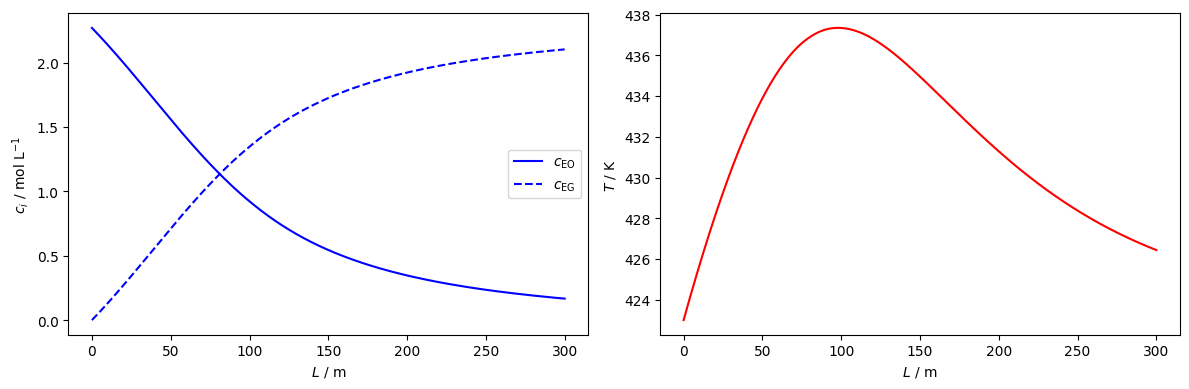

In [14]:
# Initial (inlet) conditions
f_init = np.array([c_10, c_20, T_0])

# Solve
Lspan = np.array([0, L_R])
leval = np.linspace(0, Lspan[1], 2001)
sol = integ.solve_ivp(PFTR_constant_h, Lspan, f_init, method='BDF', t_eval=leval)

# POSTPROCESSING & PLOTTING

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.set(xlabel='$L$ / m', ylabel='$c_i$ / mol L$^{-1}$')
ax1.plot(sol.t, sol.y[0, :] / 1000, 'b-',  label='$c_{\\mathrm{EO}}$')
ax1.plot(sol.t, sol.y[1, :] / 1000, 'b--', label='$c_{\\mathrm{EG}}$')
ax1.legend()

ax2.set(xlabel='$L$ / m', ylabel='$T$ / K')
ax2.plot(sol.t, sol.y[2, :], 'r-')

fig.tight_layout()
plt.show()

The base-case simulation shows the consumption of ethylene oxide (EO) and the formation of ethylene glycol (EG) along the reactor length. As expected, the EO concentration decreases continuously while the EG concentration increases due to the reaction. The temperature initially rises because of the exothermic reaction and reaches a maximum around the middle of the reactor. Further downstream, heat transfer to the reactor wall causes the temperature to decrease gradually.

### 5.5 Sensitivity Analysis Setup

A generalized reactor model is defined to evaluate the influence of different operating parameters on reactor performance. The wall heat-transfer coefficient, inlet concentration, and inlet temperature are varied while keeping the remaining parameters constant

In [15]:
#%%

def PFTR(L, f, h, T_in):
    c_1, c_2, T = f[0], f[1], f[2]
    r = kinetics(T, c_1)
    dc_1dL = -r / u
    dc_2dL =  r / u
    dTdL = (-H_R * r / C - h * a_wall * (T - T_wall) / C) / u
    dfdL = np.empty_like(f)
    dfdL[0] = dc_1dL
    dfdL[1] = dc_2dL
    dfdL[2] = dTdL
    return dfdL

Lspan = np.array([0, L_R])
leval = np.linspace(0, Lspan[1], 2001)


### 5.6 Effect of Wall Heat Transfer Coefficient

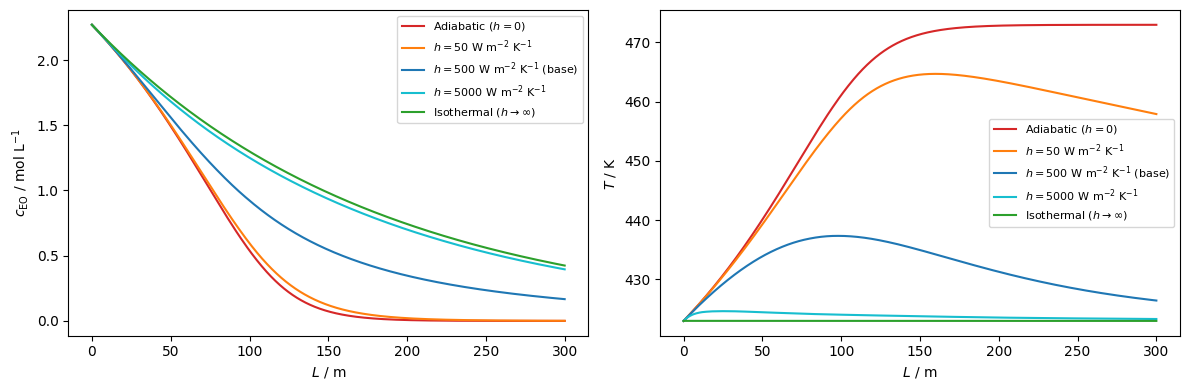

In [16]:
#%%
# Sensitivity 1: Cooling Power (h_wall)

h_cases = {
    'Adiabatic ($h = 0$)':                   0,
    '$h = 50$ W m$^{-2}$ K$^{-1}$':         50,
    '$h = 500$ W m$^{-2}$ K$^{-1}$ (base)': 500,
    '$h = 5000$ W m$^{-2}$ K$^{-1}$':       5000,
    'Isothermal ($h \\to \\infty$)':         1e6,
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.set(xlabel='$L$ / m', ylabel='$c_{\\mathrm{EO}}$ / mol L$^{-1}$')
ax2.set(xlabel='$L$ / m', ylabel='$T$ / K')
colors = ['tab:red', 'tab:orange', 'tab:blue', 'tab:cyan', 'tab:green']

for (label, h), color in zip(h_cases.items(), colors):
    f_init = np.array([c_10, c_20, T_0])
    sol = integ.solve_ivp(PFTR, Lspan, f_init, args=(h, T_0), method='BDF', t_eval=leval)
    ax1.plot(sol.t, sol.y[0, :] / 1000, color=color, label=label)
    ax2.plot(sol.t, sol.y[2, :],         color=color, label=label)

ax1.legend(fontsize=8)
ax2.legend(fontsize=8)
fig.tight_layout()
plt.show()


The influence of the wall heat-transfer coefficient was investigated by varying the cooling intensity from adiabatic operation to nearly isothermal conditions. Lower heat-transfer coefficients result in higher reactor temperatures because less heat is removed from the system. Consequently, reaction rates increase and higher conversions are achieved over shorter reactor lengths. Increasing the heat-transfer coefficient suppresses the temperature rise and leads to lower reaction rates. Under nearly isothermal conditions, the reactor temperature remains close to the wall temperature throughout the reactor.

### 5.7 Effect of Inlet EO Concentration

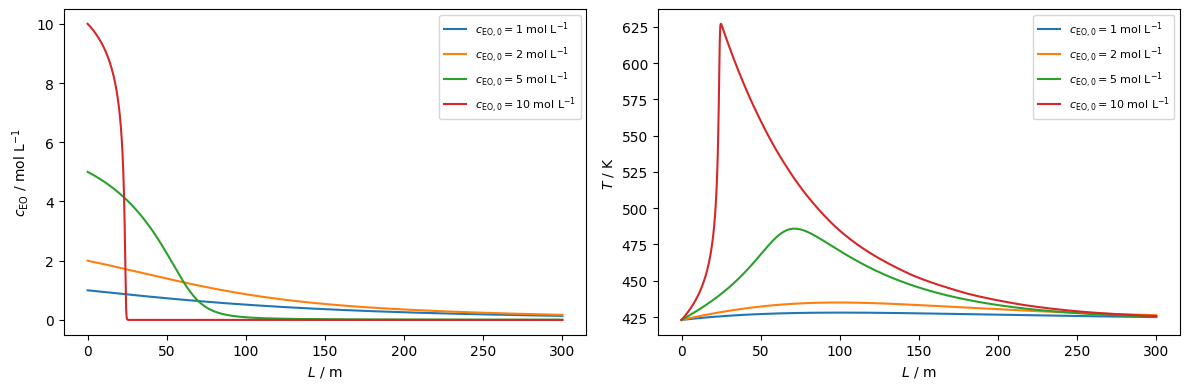

In [17]:
#%%
# Sensitivity 2: Inlet Concentration (base: h=500, T_0=423 K)

c_cases = {
    '$c_{\\mathrm{EO,0}} = 1$ mol L$^{-1}$':  1000,
    '$c_{\\mathrm{EO,0}} = 2$ mol L$^{-1}$':  2000,
    '$c_{\\mathrm{EO,0}} = 5$ mol L$^{-1}$':  5000,
    '$c_{\\mathrm{EO,0}} = 10$ mol L$^{-1}$': 10000,
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.set(xlabel='$L$ / m', ylabel='$c_{\\mathrm{EO}}$ / mol L$^{-1}$')
ax2.set(xlabel='$L$ / m', ylabel='$T$ / K')
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for (label, c_in), color in zip(c_cases.items(), colors):
    f_init = np.array([c_in, c_20, T_0])
    sol = integ.solve_ivp(PFTR, Lspan, f_init, args=(h_wall, T_0), method='BDF', t_eval=leval)
    ax1.plot(sol.t, sol.y[0, :] / 1000, color=color, label=label)
    ax2.plot(sol.t, sol.y[2, :],         color=color, label=label)

ax1.legend(fontsize=8)
ax2.legend(fontsize=8)
fig.tight_layout()
plt.show()

The inlet concentration of ethylene oxide strongly influences both conversion and temperature profiles. Higher inlet concentrations increase the reaction rate and generate more reaction heat. As a result, larger temperature peaks are observed and the reactant is consumed more rapidly. At low inlet concentrations, the temperature increase remains moderate and conversion proceeds more gradually along the reactor length.

### 5.8 Effect of Inlet Temperature

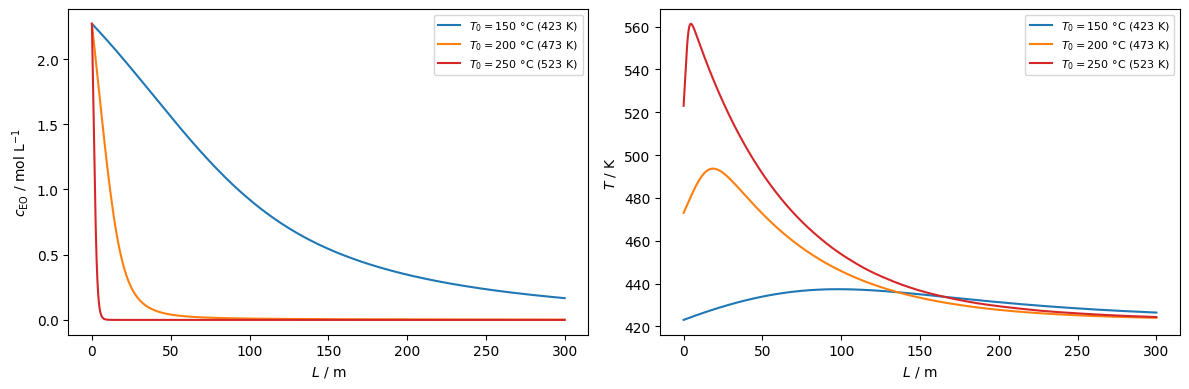

In [18]:
#%%
# Sensitivity 3: Inlet Temperature (base: h=500, c_10=2270 mol/m^3)
# 150°C = 423 K, 200°C = 473 K, 250°C = 523 K

T_cases = {
    '$T_0 = 150$ °C (423 K)': 423,
    '$T_0 = 200$ °C (473 K)': 473,
    '$T_0 = 250$ °C (523 K)': 523,
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.set(xlabel='$L$ / m', ylabel='$c_{\\mathrm{EO}}$ / mol L$^{-1}$')
ax2.set(xlabel='$L$ / m', ylabel='$T$ / K')
colors = ['tab:blue', 'tab:orange', 'tab:red']

for (label, T_in), color in zip(T_cases.items(), colors):
    f_init = np.array([c_10, c_20, T_in])
    sol = integ.solve_ivp(PFTR, Lspan, f_init, args=(h_wall, T_in), method='BDF', t_eval=leval)
    ax1.plot(sol.t, sol.y[0, :] / 1000, color=color, label=label)
    ax2.plot(sol.t, sol.y[2, :],         color=color, label=label)

ax1.legend(fontsize=8)
ax2.legend(fontsize=8)
fig.tight_layout()
plt.show()

The effect of inlet temperature was studied by comparing reactor operation at 150°C, 200°C, and 250°C. Increasing the inlet temperature significantly accelerates the reaction because of the Arrhenius dependence of the reaction rate constant. Consequently, ethylene oxide is consumed much faster and higher temperature peaks are observed. Lower inlet temperatures lead to slower reaction rates and lower overall conversion within the reactor.
